## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
# @title Ingrese datos
nombre_estudiante = "Yorleny Aguillar, Nicolle Rodriguez, Juan Jose Garcia" # @param {"type":"string"}
carnet = None # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

Una tienda maneja un volumen creciente de productos en su inventario. Actualmente, los registros se ingresan de forma desordenada en el sistema, lo que provoca que los vendedores pierdan tiempo valioso intentando localizar un artículo específico para verificar su precio o disponibilidad. Se requiere diseñar e implementar un algoritmo que organice el inventario de forma eficiente y permita realizar consultas en el menor tiempo posible, optimizando así la atención al cliente.



## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.



## 3) Historias de usuario **[2 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:
Incluye criterios de aceptación.


## 4) Diagramas de flujo **[5 pts]**
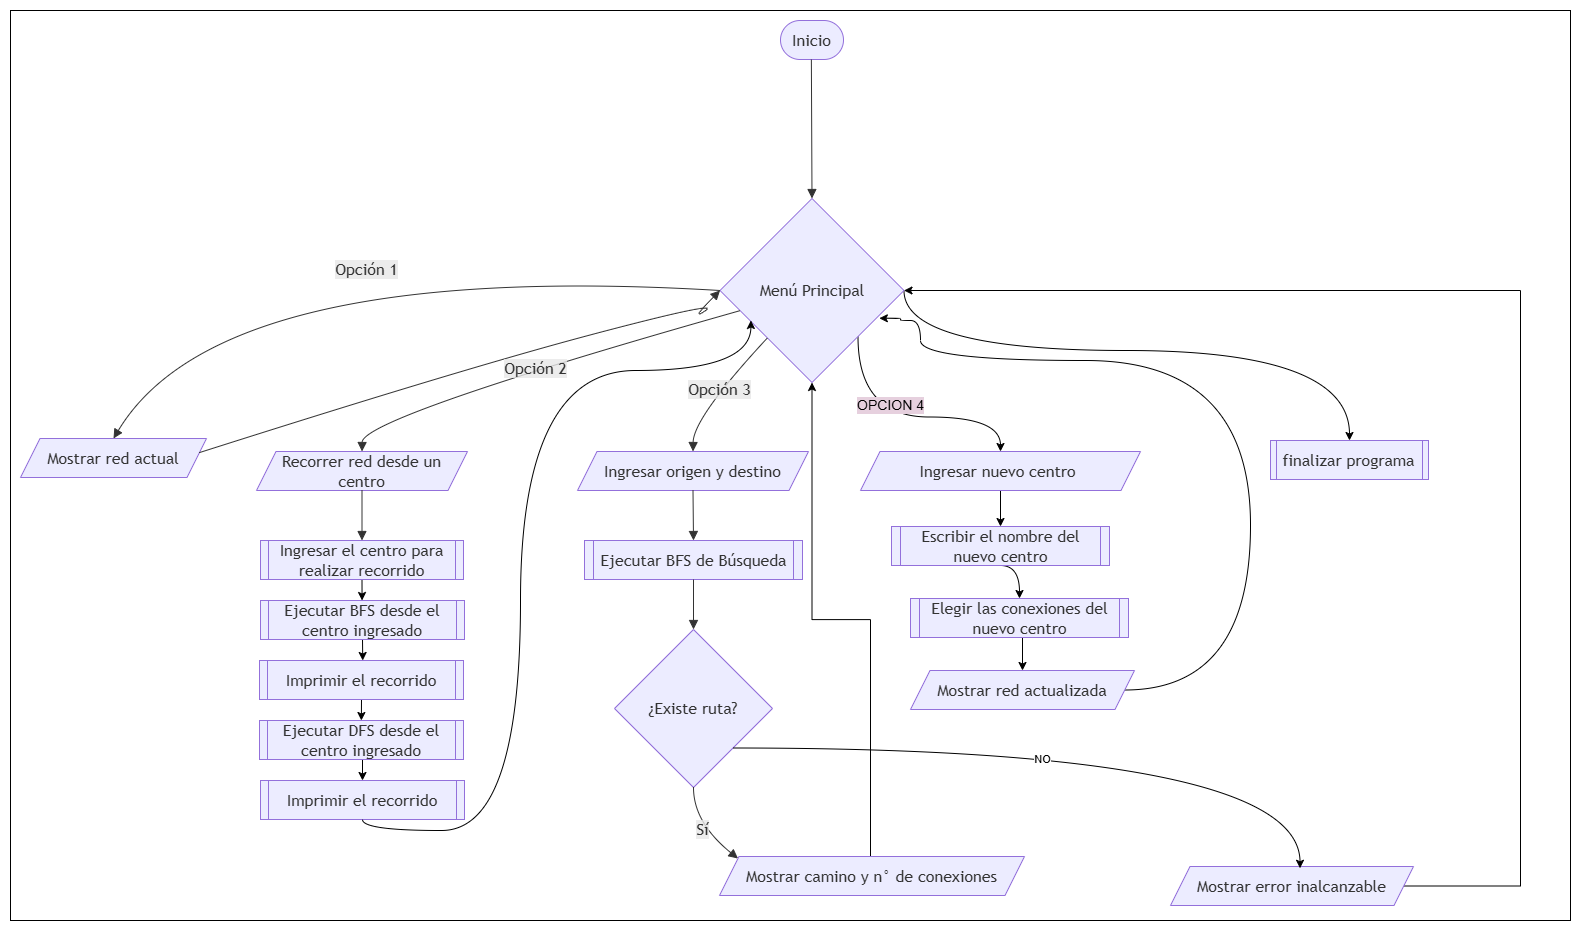

### 5) Análisis de complejidad **[15 pts]**
Incluye:
- Justificación
- Función T[n]
- Mejor y peor caso con gráfica


## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

def obtener_grafo_base():
    return {
        "A": ["B", "C"],
        "B": ["A", "D", "E"],
        "C": ["A", "F"],
        "D": ["B"],
        "E": ["B", "G"],
        "F": ["C", "G"],
        "G": ["E", "F"]
    }

def mostrar_grafo_texto(grafo):
    print("\n--- Lista de adyacencia ---")
    for nodo, vecinos in grafo.items():
        print(f'{nodo}: {vecinos}')

def visualizar_recorrido_grafo(grafo_base, aristas_recorrido, nodos_orden, titulo):
    """
    Dibuja el grafo base en gris y resalta con flechas el recorrido exacto del algoritmo.
    """
    G_base = nx.Graph(grafo_base)
    # Semilla fija para mantener la forma geométrica de la red
    pos = nx.spring_layout(G_base, seed=42)

    plt.figure(figsize=(9, 6))

    # 1. Dibujar grafo original de fondo (Gris claro)
    nx.draw_networkx_nodes(G_base, pos, node_color='#EEEEEE', node_size=800, edgecolors='#CCCCCC')
    nx.draw_networkx_edges(G_base, pos, edge_color='#E0E0E0', width=2, style='dashed')

    # 2. Construir y dibujar el grafo dirigido del recorrido (Flechas azules/verdes)
    G_recorrido = nx.DiGraph()
    G_recorrido.add_nodes_from(nodos_orden)
    G_recorrido.add_edges_from(aristas_recorrido)

    color_nodo = '#99CCFF' if 'BFS' in titulo else '#FFCC99'
    color_borde = 'blue' if 'BFS' in titulo else 'darkorange'
    if 'Búsqueda' in titulo:
        color_nodo = '#99FF99'
        color_borde = 'green'

    # Nodos visitados
    nx.draw_networkx_nodes(G_recorrido, pos, node_color=color_nodo, node_size=800, edgecolors=color_borde)

    # Aristas transitadas (Flechas)
    nx.draw_networkx_edges(G_recorrido, pos, edgelist=aristas_recorrido,
                           edge_color=color_borde, width=2.5,
                           arrows=True, arrowsize=20)

    # Etiquetas con el orden numérico de visita
    etiquetas = {nodo: f"{nodo}\n({nodos_orden.index(nodo)+1})" for nodo in nodos_orden}
    nx.draw_networkx_labels(G_recorrido, pos, labels=etiquetas, font_size=10, font_weight='bold')

    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

def recorrido_bfs(grafo, inicio):
    if inicio not in grafo:
        print(f"\nError: El centro '{inicio}' no existe.")
        return

    visitados = set([inicio])
    # Cola almacena: (nodo_actual, nivel, nodo_padre_que_lo_descubrió)
    cola = deque([(inicio, 0, None)])

    orden = []
    niveles = {}
    aristas_recorridas = [] # Guarda los vectores dibujables

    while cola:
        nodo_actual, nivel_actual, padre = cola.popleft()
        orden.append(nodo_actual)

        if padre is not None:
            aristas_recorridas.append((padre, nodo_actual))

        if nivel_actual not in niveles:
            niveles[nivel_actual] = []
        niveles[nivel_actual].append(nodo_actual)

        for vecino in grafo[nodo_actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append((vecino, nivel_actual + 1, nodo_actual))

    print(f"\nRecorrido BFS desde {inicio}:")
    print(" -> ".join(orden))
    for nivel, nodos in niveles.items():
        print(f"Nivel {nivel}: {', '.join(nodos)}")

    visualizar_recorrido_grafo(grafo, aristas_recorridas, orden, f"Árbol de Recorrido BFS (desde {inicio})")

def recorrido_dfs(grafo, nodo, visitados=None, orden=None, aristas=None, padre=None, es_raiz=True):
    if visitados is None:
        if nodo not in grafo:
            print(f"\nError: El centro '{nodo}' no existe.")
            return []
        visitados = set()
        orden = []
        aristas = []
        if es_raiz:
            print(f"\nRecorrido DFS desde {nodo}:")

    visitados.add(nodo)
    orden.append(nodo)

    if padre is not None:
        aristas.append((padre, nodo))

    for vecino in grafo.get(nodo, []):
        if vecino not in visitados:
            recorrido_dfs(grafo, vecino, visitados, orden, aristas, nodo, es_raiz=False)

    if es_raiz:
        print(" -> ".join(orden))
        visualizar_recorrido_grafo(grafo, aristas, orden, f"Árbol de Recorrido DFS (desde {nodo})")

    return orden

def buscar_ruta_bfs(grafo, inicio, objetivo):
    if inicio not in grafo or objetivo not in grafo:
        print("\nError: Uno o ambos centros no existen.")
        return

    visitados = set([inicio])
    cola = deque([(inicio, [inicio])])

    while cola:
        nodo_actual, ruta = cola.popleft()

        if nodo_actual == objetivo:
            conexiones = len(ruta) - 1
            print(f"\nCentro encontrado. Ruta: {' -> '.join(ruta)}")
            print(f"Cantidad de conexiones: {conexiones}")

            # Extraer aristas secuenciales de la ruta final para graficar
            aristas_ruta = [(ruta[i], ruta[i+1]) for i in range(len(ruta)-1)]
            visualizar_recorrido_grafo(grafo, aristas_ruta, ruta, f"Búsqueda de Ruta: {inicio} a {objetivo}")
            return ruta

        for vecino in grafo[nodo_actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                nueva_ruta = list(ruta)
                nueva_ruta.append(vecino)
                cola.append((vecino, nueva_ruta))

    print("\nNo existe una ruta hasta el centro solicitado.")
    return None

def agregar_centro(grafo):
    nuevo_centro = input("\nIngrese el nombre del nuevo centro: ").strip().upper()
    if nuevo_centro in grafo:
        print("El centro ya existe.")
        return

    grafo[nuevo_centro] = []
    while True:
        vecino = input(f"Conectar {nuevo_centro} con (Enter para finalizar): ").strip().upper()
        if not vecino:
            break

        if vecino in grafo:
            if vecino not in grafo[nuevo_centro]:
                grafo[nuevo_centro].append(vecino)
                grafo[vecino].append(nuevo_centro)
                print(f"Conexión agregada: {nuevo_centro} - {vecino}")
            else:
                print("La conexión ya existe.")
        else:
            print("El centro ingresado no existe.")

def ejecutar_sistema():
    grafo = obtener_grafo_base()

    while True:
        print("\n" + "="*45)
        print("   MENÚ DE RED DE DISTRIBUCIÓN LOGÍSTICA")
        print("="*45)
        print("1. Mostrar red actual (Texto y Gráfico base)")
        print("2. Recorrer red desde un centro (Genera Grafo BFS y DFS)")
        print("3. Buscar ruta entre dos centros (Genera Grafo de Ruta)")
        print("4. Ampliar la red (Agregar centro)")
        print("5. Salir")

        opcion = input("\nSeleccione una opción: ").strip()

        if opcion == '1':
            mostrar_grafo_texto(grafo)
            visualizar_recorrido_grafo(grafo, [], list(grafo.keys()), "Red Logística Completa")

        elif opcion == '2':
            inicio = input("\nIngrese el centro inicial: ").strip().upper()
            if inicio in grafo:
                recorrido_bfs(grafo, inicio)
                recorrido_dfs(grafo, inicio)
            else:
                print("El centro ingresado no existe.")

        elif opcion == '3':
            inicio_busq = input("Centro origen: ").strip().upper()
            obj_busq = input("Centro destino: ").strip().upper()
            buscar_ruta_bfs(grafo, inicio_busq, obj_busq)

        elif opcion == '4':
            agregar_centro(grafo)
            print("Red actualizada.")
            visualizar_recorrido_grafo(grafo, [], list(grafo.keys()), "Red Logística Ampliada")

        elif opcion == '5':
            break
        else:
            print("Opción inválida.")

if __name__ == "__main__":
    ejecutar_sistema()

## 7) Tests aplicados **[15 pts]**

In [ ]:
# 1. Test de ordenamiento
inventario_test = [
    {"id": 3, "nombre": "C"},
    {"id": 1, "nombre": "A"},
    {"id": 2, "nombre": "B"}
]
inventario_test_ordenado = merge_sort(inventario_test)
# Verificamos que el primer elemento sea el de ID más bajo
assert inventario_test_ordenado[0]['id'] == 1, "Fallo: El arreglo no se ordenó correctamente"
assert inventario_test_ordenado[-1]['id'] == 3, "Fallo: El arreglo no se ordenó correctamente"

# 2. Test de búsqueda exitosa (Mejor caso / Caso intermedio)
# Usando el inventario_ordenado del bloque funcional anterior
resultado_exitoso = busqueda_binaria(inventario_ordenado, 512)
assert resultado_exitoso is not None, "Fallo: No se encontró un producto que sí existe"
assert resultado_exitoso['nombre'] == "Memoria RAM 16GB", "Fallo: Se recuperaron datos incorrectos del producto"

# 3. Test de búsqueda en los extremos (Peor caso en datos existentes)
resultado_extremo = busqueda_binaria(inventario_ordenado, 899)
assert resultado_extremo['nombre'] == "Monitor 24 pulgadas", "Fallo: No se encontró el elemento en el límite superior"

# 4. Test de búsqueda de elemento inexistente (Peor caso global)
resultado_fallido = busqueda_binaria(inventario_ordenado, 999)
assert resultado_fallido is None, "Fallo: Retornó un producto para un ID que no existe"

print("¡Todos los tests pasaron correctamente!")

¡Todos los tests pasaron correctamente!
